# Steel Girder Bridge — Conceptual Design & Validation Walkthrough

**Continuous steel plate girder, composite concrete deck (5 spans).**

This notebook is the *validation harness* for civilpy's hub-and-spoke bridge
pipeline: it walks a single crossing from bare ground to a faithfully
represented analysis model, and every step calls the real civilpy functions so
we can see them working (or not). The canonical `StructuralModel` **hub** is the
source of truth; Rhino (geometry) and MIDAS (analysis) are spokes fed from it.

The stages:

1. **Import a terrain model** (OGRIP LiDAR, with a synthetic fallback so the
   notebook always runs).
2. **Establish an alignment** — you can't drape an alignment on the ground; you
   pick two points and a curvature, and civilpy derives bearing, length, and
   grade.
3. **Specify the bridge type** — civilpy's feasibility checks start here and
   *redirect* infeasible choices (a 690 ft single-span slab is not allowed).
4. **Span configuration** — the first planning/analysis phase: real dead-load
   reactions and an HL-93 shear/moment envelope, plus the **faithful full-bridge
   refined grillage** for MIDAS — bare-steel girders + a physical deck of plate
   elements tied by rigid links, with a **composite / non-composite toggle**.
5. **Construction staging & maintenance of traffic** — build in phases, shift
   the lanes onto the girders carrying traffic, add an anchored portable
   barrier, and check a closure pour.

> Units: feet, kips, k-ft throughout. Plan frame `x = East`, `y = North`.


In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

import civilpy
print("civilpy", getattr(civilpy, "__version__", "(editable)"))
np.set_printoptions(suppress=True)


civilpy (editable)


## 1. Import a terrain model from OGRIP

`Terrain.from_ogrip(bbox_wgs84)` fetches Ohio's OGRIP LiDAR tiles for a WGS84
bounding box and builds a TIN (scipy Delaunay) with barycentric elevation
lookup. Live tile fetching needs network + `requests` and is disclaimed
(the tile-URL field hasn't been live-verified), so this cell **falls back to a
synthetic valley terrain** in the same coordinate frame when OGRIP is
unavailable — the rest of the notebook is identical either way.

The site is a stream valley: high ground at both abutments (~x = 0 and
x = 690 ft) dropping ~45 ft to the valley floor at mid-crossing, with a gentle
overall rise so the two abutments differ in elevation (that difference becomes
the roadway grade in Section 2).


In [2]:
from civilpy.transportation.terrain import Terrain


def synthetic_valley_terrain(seed: int = 7) -> Terrain:
    """A stream-valley ground surface over the bridge corridor (feet)."""
    rng = np.random.default_rng(seed)
    xs = np.linspace(-100.0, 790.0, 90)
    ys = np.linspace(-160.0, 160.0, 40)
    pts = []
    for x in xs:
        for y in ys:
            # valley across the crossing + 2% longitudinal rise + cross-fall
            valley = 45.0 * np.exp(-((x - 345.0) / 150.0) ** 2)
            z = 520.0 - valley + 0.020 * x - 0.010 * abs(y)
            z += rng.normal(0.0, 0.15)          # survey noise
            pts.append((x, y, z))
    return Terrain.from_points(np.array(pts))


# WGS84 bbox near the (fictional) site; swap for a real crossing at ODOT.
bbox_wgs84 = (-83.010, 40.000, -83.000, 40.008)
try:
    terrain = Terrain.from_ogrip(bbox_wgs84)
    source = "OGRIP LiDAR"
except Exception as exc:                          # network / laspy / URL field
    warnings.warn(f"OGRIP fetch unavailable ({type(exc).__name__}: {exc}); "
                  "using synthetic valley terrain.")
    terrain = synthetic_valley_terrain()
    source = "synthetic valley (fallback)"

xy = terrain.points[:, :2]
print(f"terrain source : {source}")
print(f"points         : {len(terrain.points):,}")
print(f"x range (ft)   : {xy[:,0].min():.0f} .. {xy[:,0].max():.0f}")
print(f"y range (ft)   : {xy[:,1].min():.0f} .. {xy[:,1].max():.0f}")
print(f"elev range (ft): {terrain.points[:,2].min():.1f} .. "
      f"{terrain.points[:,2].max():.1f}")
print(f"elev at abutments: x=0 -> {terrain.elevation_at(0.0, 0.0):.1f}, "
      f"x=690 -> {terrain.elevation_at(690.0, 0.0):.1f}")


C:\Users\dane\PycharmProjects\civilpy\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


terrain source : synthetic valley (fallback)
points         : 3,600
x range (ft)   : -100 .. 790
y range (ft)   : -160 .. 160
elev range (ft): 480.1 .. 535.8
elev at abutments: x=0 -> 519.7, x=690 -> 533.4


C:\Users\dane\AppData\Local\Temp\ipykernel_44348\4289678400.py:26: UserWarning: OGRIP fetch unavailable (HTTPError: 404 Client Error: Not Found for url: https://gis1.oit.ohio.gov/arcgis/rest/services/OSIP_III/MapServer/0/query?geometry=-83.01%2C40.0%2C-83.0%2C40.008&geometryType=esriGeometryEnvelope&spatialRel=esriSpatialRelIntersects&outFields=%2A&returnGeometry=true&f=json); using synthetic valley terrain.
  warnings.warn(f"OGRIP fetch unavailable ({type(exc).__name__}: {exc}); "


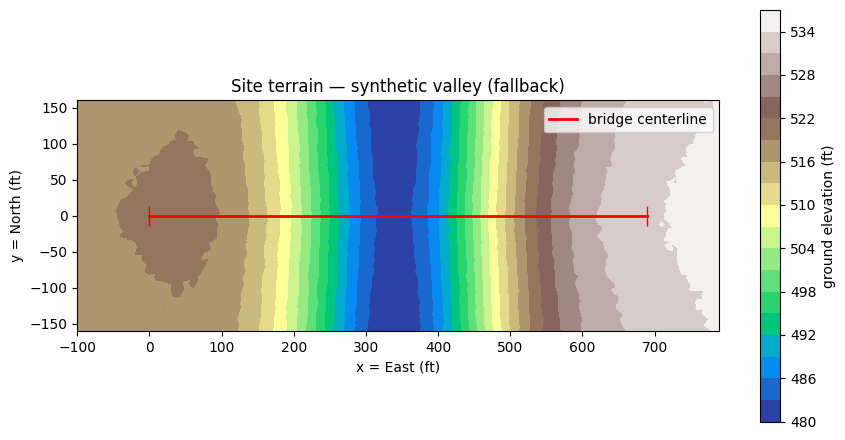

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tri = ax.tricontourf(terrain.points[:,0], terrain.points[:,1],
                     terrain.points[:,2], levels=18, cmap="terrain")
fig.colorbar(tri, ax=ax, label="ground elevation (ft)")
ax.plot([0, 690], [0, 0], "r-", lw=2, label="bridge centerline")
ax.plot([0, 690], [0, 0], "r|", ms=14)
ax.set_xlabel("x = East (ft)"); ax.set_ylabel("y = North (ft)")
ax.set_title(f"Site terrain — {source}"); ax.legend(loc="upper right")
ax.set_aspect("equal"); plt.tight_layout(); plt.show()


## 2. Establish an alignment

You cannot simply drape an alignment on a TIN — an alignment is a *designed*
geometry. The conceptual-design move is to **pick two points and a curvature**;
civilpy back-computes the bearing and length (and, for a curve, the deflection
from the chord), then derives the **grade** by sampling the terrain at each end.

`Alignment.between_points(p0, p1, terrain=...)` does exactly this. Here the two
points are the abutment locations; with no radius the through-line is a tangent.
The resulting profile grade is the terrain-driven slope between abutments.


In [4]:
from civilpy.transportation.alignment import Alignment

abut_1 = (0.0, 0.0)
abut_2 = (690.0, 0.0)
al = Alignment.between_points(abut_1, abut_2, start_station_ft=1000.0,
                              terrain=terrain)

z0 = al.elevation_at(al.start_station)
z1 = al.elevation_at(al.end_station)
grade = (z1 - z0) / al.length_ft * 100.0
print(f"length      : {al.length_ft:.1f} ft")
print(f"bearing     : {al.bearing_at(al.start_station):.2f} deg (cw from N)")
print(f"start sta    : {al.start_station:.0f}  ->  end sta {al.end_station:.0f}")
print(f"abut elevs   : {z0:.2f} ft  ->  {z1:.2f} ft")
print(f"grade        : {grade:+.2f}%  (derived from terrain)")

# a curved alternative, to show the two-point + radius path
al_curved = Alignment.between_points(abut_1, abut_2, radius_ft=2500.0,
                                     direction="R", terrain=terrain)
print(f"\ncurved option: R=2500 ft -> arc length {al_curved.length_ft:.1f} ft")


length      : 690.0 ft
bearing     : 90.00 deg (cw from N)
start sta    : 1000  ->  end sta 1690
abut elevs   : 519.70 ft  ->  533.41 ft
grade        : +1.99%  (derived from terrain)

curved option: R=2500 ft -> arc length 692.2 ft


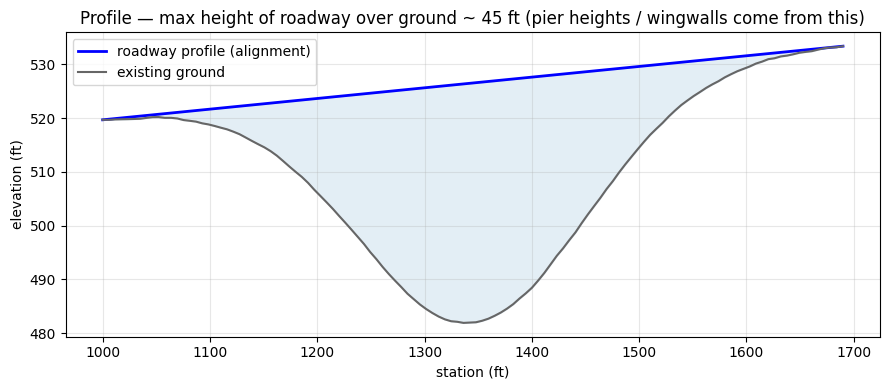

In [5]:
# Roadway profile vs. ground along the alignment: the payoff of the terrain.
stations = np.linspace(al.start_station, al.end_station, 120)
road_z = np.array([al.elevation_at(s) for s in stations])
grnd_z = np.array([terrain.elevation_along(al, s, 0.0) for s in stations])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(stations, road_z, "b-", lw=2, label="roadway profile (alignment)")
ax.plot(stations, grnd_z, color="0.4", lw=1.5, label="existing ground")
ax.fill_between(stations, grnd_z, road_z, where=road_z > grnd_z,
                color="tab:blue", alpha=0.12)
ax.set_xlabel("station (ft)"); ax.set_ylabel("elevation (ft)")
clr = float(np.max(road_z - grnd_z))
ax.set_title(f"Profile — max height of roadway over ground ~ {clr:.0f} ft "
             "(pier heights / wingwalls come from this)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 3. Specify the bridge type — civilpy's checks kick in

Before any detailing, civilpy's `bridge_type.assess` gates the choice. Ask for
the wrong thing — a **single-span reinforced concrete slab** across the whole
690 ft — and it must be rejected and *redirected* to a continuous long-span
type. The redirect even re-splits the crossing into a feasible continuous unit.


In [6]:
from civilpy.structural import bridge_type

total_ft = al.length_ft   # 690 ft crossing

bad = bridge_type.assess("rc_slab", [total_ft])
print(bad.summary())
print()
print("allowed:", bad.allowed)


Reinforced concrete slab (single span) for single span: INFEASIBLE
  - controlling span 690 ft exceeds the ~40 ft ceiling for Reinforced concrete slab (single span).
  Recommended instead:
    * Continuous steel plate girder, composite deck: 2 spans of ~345 ft -- continuous 2-span unit keeps each span in the 90-400 ft range
    * Prestressed I-girder, composite deck: 5 spans of ~138 ft -- continuous 5-span unit keeps each span in the 40-160 ft range
    * Steel rolled-beam, composite deck (marginal): 6 spans of ~115 ft -- continuous 6-span unit keeps each span in the 40-120 ft range

allowed: False


Taking the redirect, we adopt a **continuous steel plate girder** and lay
out a balanced 5-span arrangement (shorter end spans, ~0.8 of the interior).
`assess` confirms the arrangement sits comfortably in the type's range.

In [7]:
# balanced 5-span: end spans ~0.8 * interior, summing to the crossing length
interior = total_ft / (0.8 + 3 + 0.8)
spans = (round(0.8*interior,1), round(interior,1), round(interior,1),
         round(interior,1), round(0.8*interior,1))
print("proposed spans (ft):", spans, "sum =", round(sum(spans),1))

good = bridge_type.assess("steel_plate_girder", list(spans))
print()
print(good.summary())


proposed spans (ft): (120.0, 150.0, 150.0, 150.0, 120.0) sum = 690.0

Continuous steel plate girder, composite deck for 5 spans, max 150 ft: OK
  - controlling span 150 ft sits comfortably in the 90-400 ft range for Continuous steel plate girder, composite deck.


## 4. Span configuration — first planning/analysis phase

Now the engineer sets the cross-section: **roadway width, number of lanes,
girder count/spacing, section, and parapet type.** From these civilpy builds the
full bridge layout (deck thickness + rebar mats from the ODOT BDM standard
design), then produces:

* **real dead-load reactions** per girder line (native continuous-beam analysis),
* an **HL-93 shear/moment envelope** (influence-line moving load), and
* the **faithful full-bridge hub** → MIDAS payloads (every girder + diaphragm +
  support + load — not a 1-ft strip), ready to host traffic lanes for a
  moving-load run.


In [ ]:
from civilpy.structural.bridge_layout import (
    BridgeInput, layout_bridge, structural_model_from_layout, girder_line_loads)

# ---- design inputs the engineer chooses -------------------------------------
roadway_width_ft = 40.0      # curb-to-curb (e.g. 2 x 12 ft lanes + shoulders)
lane_width_ft    = 12.0      # design lane width — drives the traffic lines
n_lanes          = 3         # design lanes for live load
girder_count     = 5
girder_spacing   = 9.0       # ft, c/c
section_label    = "W40X211" # trial rolled section (plate girder in final)
parapet          = "SBR-1-20"
cross_slope_pct  = 2.0       # deck crown/cross slope — sets the seat elevations
overhang         = (roadway_width_ft - (girder_count-1)*girder_spacing)/2.0

inp = BridgeInput(spans_ft=spans, girder_count=girder_count,
                  girder_spacing_ft=girder_spacing, girder_label=section_label,
                  overhang_ft=round(overhang,2), railing=parapet,
                  grade="Grade 50W", deck_thickness_in=9.0,
                  cross_slope_pct=cross_slope_pct)
layout = layout_bridge(inp)

print(f"deck width      : {layout.deck_width_ft:.1f} ft  "
      f"(overhang {inp.overhang_ft:.2f} ft each side)")
print(f"effective span  : {layout.effective_span_ft:.2f} ft (deck design span)")
print(f"deck thickness  : {layout.deck.thickness_in:.2f} in")
print(f"cross slope     : {inp.cross_slope_pct:.1f}%  -> girder seat elevations "
      f"vary across the width (crown-driven, not rounded)")
print(f"total length    : {layout.total_length_ft:.0f} ft")


In [9]:
from civilpy.structural.continuous_beam import ContinuousBeam

# support stations along the girder line
stz = [0.0]
for s in inp.spans_ft:
    stz.append(stz[-1] + s)

print("Dead-load reactions per girder line (kip, up +):")
print(f"  supports at (ft): {[round(s) for s in stz]}")
header = f"  {'girder':<8}{'w DL klf':>10}" + "".join(
    f"{'R'+str(i+1):>8}" for i in range(len(stz)))
print(header)
for g in range(girder_count):
    w = girder_line_loads(layout, g)
    w_dl = w["dc1"] + w["dc2"] + w["dw"]
    beam = ContinuousBeam(stz); beam.add_udl(w_dl)
    R = beam.reactions()
    print(f"  G{g+1:<7}{w_dl:>10.3f}" + "".join(f"{r:>8.1f}" for r in R))


Dead-load reactions per girder line (kip, up +):
  supports at (ft): [0, 120, 270, 420, 570, 690]
  girder    w DL klf      R1      R2      R3      R4      R5      R6
  G1           1.787    79.8   268.2   268.6   268.6   268.2    79.8
  G2           1.764    78.8   264.6   265.0   265.0   264.6    78.8
  G3           1.764    78.8   264.6   265.0   265.0   264.6    78.8
  G4           1.764    78.8   264.6   265.0   265.0   264.6    78.8
  G5           1.787    79.8   268.2   268.6   268.6   268.2    79.8


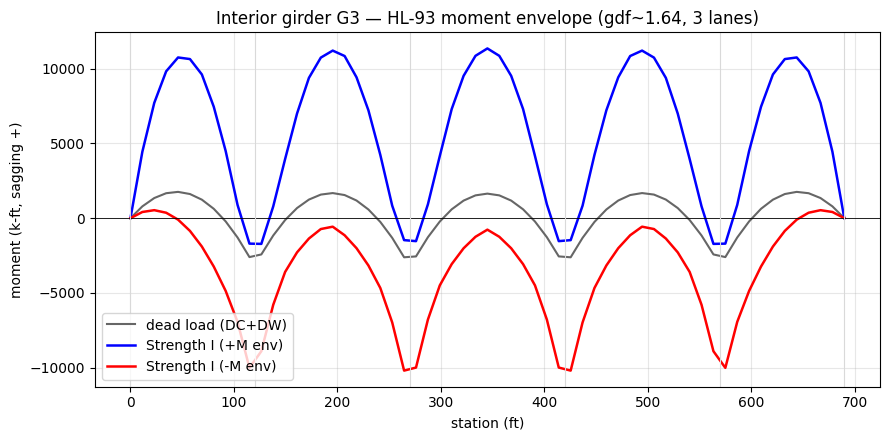

max +M = 11,348 k-ft  |  max -M = -10,192 k-ft


In [10]:
from civilpy.structural.girder_pipeline import girder_line_envelope

# HL-93 shear/moment envelope for an interior girder line (line 3).
gi = girder_count // 2
w = girder_line_loads(layout, gi)
# approximate interior distribution factor (2+ lanes); the rigorous LRFD
# factors live in civilpy.structural.aashto.lrfd.distribution
gdf = min(n_lanes, girder_spacing / 5.5)

st, mom = girder_line_envelope(
    stz, dc1_klf=w["dc1"], dc2_klf=w["dc2"], dw_klf=w["dw"],
    n_sections=61, gdf=gdf)

dc = np.array(mom["dc1"]) + np.array(mom["dc2"]) + np.array(mom["dw"])
strength_pos = 1.25*dc + 1.75*np.array(mom["ll_pos"])
strength_neg = 1.25*dc + 1.75*np.array(mom["ll_neg"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(st, dc, color="0.4", lw=1.5, label="dead load (DC+DW)")
ax.plot(st, strength_pos, "b-", lw=1.8, label="Strength I (+M env)")
ax.plot(st, strength_neg, "r-", lw=1.8, label="Strength I (-M env)")
ax.axhline(0, color="k", lw=0.6)
for s in stz: ax.axvline(s, color="0.85", lw=0.8)
ax.set_xlabel("station (ft)"); ax.set_ylabel("moment (k-ft, sagging +)")
ax.set_title(f"Interior girder G{gi+1} — HL-93 moment envelope "
             f"(gdf~{gdf:.2f}, {n_lanes} lanes)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"max +M = {strength_pos.max():,.0f} k-ft  |  "
      f"max -M = {strength_neg.min():,.0f} k-ft")


### Faithful representation for MIDAS — the refined grillage

`grillage_model_from_layout` converts the layout into the canonical
`StructuralModel` hub **directly** (no Rhino round-trip) as the "deck-as-plate,
girder-as-frame" model MIDAS recommends when the full deck surface is needed for
moving-load traffic lanes:

* every girder is a continuous chain of **bare-steel** beam elements with its
  real AISC section;
* the **deck is a mesh of plate elements** (interior bays + overhangs);
* **rigid links** tie each deck node over a girder to the girder — this is the
  **composite / non-composite toggle** (`BridgeInput.composite`). Because the
  girder section stays bare steel in both cases, the deck stiffness lives only
  in the plates and is **never double-counted**.

Verified live on this bridge: the whole deck arrives in Civil NX (462 plate
elements + 385 girder beams), it solves, and the toggle changes the demand —
the bare-steel girder carries ~half the moment when the deck is composite.


In [ ]:
from civilpy.structural.bridge_layout import grillage_model_from_layout
from civilpy.structural.midas_models import midas_payloads

# Refined grillage: bare-steel girders + a physical deck of plate elements tied
# by rigid links. composite=True (studs/rebar into the deck) is the toggle.
hub = grillage_model_from_layout(layout, composite=inp.composite)
girders = [e for e in hub.elements.values() if e.role == "girder"]
plates  = [e for e in hub.elements.values() if e.role == "deck"]
print("Canonical hub (refined grillage — full bridge WITH deck):")
print(f"  nodes         : {len(hub.nodes)}")
print(f"  girder beams  : {len(girders)}  (bare steel "
      f"{sorted({e.section for e in girders})})")
print(f"  deck plates   : {len(plates)}")
print(f"  rigid links   : {len(hub.rigid_links)}   (composite={inp.composite})")
print(f"  restraints    : {len(hub.restraints)}")
print(f"  integrity     : {hub.check() or 'clean'}")

payloads = midas_payloads(hub)
print("\nMIDAS MAPI payload tables:", sorted(payloads))
print(f"  /db/NODE : {len(payloads['NODE'])}    /db/ELEM : {len(payloads['ELEM'])}"
      f"  (PLATE deck + BEAM girders)")
print(f"  /db/THIK : {len(payloads['THIK'])}      /db/RIGD : {len(payloads['RIGD'])}"
      f"  (deck thickness + composite links)")
print("  -> the whole bridge + deck goes to MIDAS, ready for moving-load lanes.")


In [ ]:
# push_midas(hub) PUTs UNIT/MATL/SECT/THIK/NODE/ELEM/RIGD/CONS/STLD/BMLD to a
# live Civil NX session and returns a per-table {"sent": n} | {"error": msg}.
# Verified live on this 5-span: the whole deck arrives (462 plate elements + 385
# girder beams + 390 composite links), it solves, and the composite toggle
# changes the demand — peak bare-steel girder Moment-y ~1004 k-ft composite vs
# ~2117 k-ft non-composite. Not run here so the notebook never touches a live model.
from civilpy.structural.midas_models import push_midas   # noqa: F401

print("At ODOT, with Civil NX open on the experiment file:")
print()
print("    from civilpy.structural.midas_models import push_midas")
print("    report = push_midas(hub)      # composite refined grillage + deck")
print("    for tbl, res in report.items(): print(tbl, res)")
print()
print("    # non-composite (no studs) is the same call on the toggled hub:")
print("    hub_nc = grillage_model_from_layout(layout, composite=False)")


## 5. Construction staging & maintenance of traffic

Bridges are built — and rehabilitated — in phases while traffic keeps moving.
The refined grillage supports this directly through
`civilpy.structural.construction_staging`:

* **phase model** — `grillage_model_from_layout(layout, girder_subset=[...])`
  builds only the girders erected so far, with the deck cantilevering to the
  mid-bay **closure joint** where the next phase begins;
* **shift the lanes** onto the girders carrying traffic
  (`lanes_over_girders`) and apply the staged live/lane load there;
* **anchored portable concrete barrier** as a temporary dead load separating
  the work zone (`add_barrier_dead_load`, catalog `PORTABLE_BARRIERS`);
* **closure pour** — the wet concrete filling the joint loads each half before
  it cures (`add_closure_pour_load`).

Each is a named load case on the hub (`MOT-LANE`, `PCB`, `CLOSURE`), so the
phases go to MIDAS through the same `midas_payloads` / `push_midas` path and can
be combined or driven as MIDAS construction stages.


In [ ]:
from civilpy.structural import construction_staging as cs

# Phase 1: girders 1-3 are built; traffic is maintained on girders 1-2 while
# girders 4-5 (phase 2) are erected alongside.
phase1 = grillage_model_from_layout(layout, girder_subset=[0, 1, 2])

lane_centers = cs.lanes_over_girders(layout, [1, 2], n_lanes=2)   # shift lanes
lane = cs.add_lane_load(phase1, layout, lane_centers)            # HL-93 lane load
pcb  = cs.add_barrier_dead_load(phase1, layout, offset_ft=16.5,  # work-zone edge
                                designation="PCB-32")
clo  = cs.add_closure_pour_load(phase1, layout, edge_girder_line=3,
                                closure_width_ft=2.0)            # wet joint strip

deck_plates = sum(1 for e in phase1.elements.values() if e.role == "deck")
print(f"Phase-1 structure (girders 1-3): {len(phase1.nodes)} nodes, "
      f"{deck_plates} deck plates, {len(phase1.restraints)} restraints")
print(f"MOT: 2 lanes shifted onto girders 1-2, centers y = "
      f"{[round(c,1) for c in lane_centers]} ft")
print(f"  lane load reaching each girder (klf) : "
      f"{ {k: round(v,3) for k,v in lane.items()} }")
print(f"  anchored PCB-32 barrier (klf)        : "
      f"{ {k: round(v,3) for k,v in pcb.items()} }")
w_strip = cs.closure_pour_line_load_plf(layout, closure_width_ft=2.0)
print(f"  closure-pour wet load on girder 3    : {clo:.3f} klf "
      f"({w_strip:.0f} plf strip, half carried each side)")
print(f"  staged load cases now: {phase1.cases()}")


**Closure pour.** Each phase carries its own dead load + staged traffic and
deflects *before* the joint is cast. The wet closure concrete then loads both
half-widths as a deck-edge cantilever; the **differential deflection** across
the still-plastic joint is what governs when — and at what relative screed
elevation — the pour is placed. Solve `phase1` and its mirror
(`girder_subset=[3, 4]`, phase 2) in MIDAS and read the deck-edge deflection at
the joint under the `CLOSURE` case to set the pour. The same phase machinery
sizes temporary shoring, stage DL for a deck replacement, and widening pours.

> Verified live in MIDAS — the staged reactions balance exactly: MOT lane load
> 883 kip, anchored PCB-32 barrier 324 kip, wet closure strip 78 kip over the
> 690 ft length.


## 6. Substructure reactions for foundation design

The bearing reactions the grillage solves for — **summed across the girders at
each support line and factored into the AASHTO combinations** — are the loads
the piers, abutments, and their foundations carry.
`civilpy.structural.substructure` pulls the per-node reactions from the solved
MIDAS model, bins them onto their substructure unit by station, and applies
Strength I / Service I.

The live load comes from the **roadway lanes**: a centerline + lane-edge lines
set by the `lane_width_ft` variable (`construction_staging.design_lanes`) — the
same lines a Rhino grip interface edits — handed to MIDAS as the HL-93 lane
load across the deck.


In [ ]:
from civilpy.structural import construction_staging as cs
from civilpy.structural import substructure as sub

# Live load from the roadway lanes: CL + lane-edge lines set by the lane-width
# variable (the same lines a Rhino grip interface edits), handed to MIDAS as the
# HL-93 lane load across the deck.
lanes = cs.design_lanes(layout, roadway_width_ft=roadway_width_ft,
                        lane_width_ft=lane_width_ft)
print(f"roadway CL at y = {lanes.cl_offset:.1f} ft; {lanes.n_lanes} design lanes "
      f"of {lanes.lane_width_ft:.0f} ft (m = {cs.multiple_presence(lanes.n_lanes)}):")
print(f"  lane-edge lines (y, ft): {list(lanes.lane_edges)}")
print(f"  lane centerlines (y,ft): {list(lanes.lane_centers)}")

# Full composite grillage already carries DC1/DC2/DW; add the lane live load.
hub_ll = grillage_model_from_layout(layout, composite=True)
cs.add_design_lane_load(hub_ll, layout, lanes)

units = sub.substructure_units(layout)
print("\nSubstructure units (one per support line):")
for u in units:
    print(f"  {u.name:<12} at station {u.station_ft:6.0f} ft")

print("\nAt ODOT — push, solve, and read the per-unit design reactions:")
print("    from civilpy.structural.midas_models import push_midas")
print("    push_midas(hub_ll); MidasCivil().analyze()")
print("    report = sub.substructure_reaction_report(")
print("        midas, hub_ll, layout, cases=['DC1','DC2','DW','LL-LANE'])")
print("    report['design']['Pier 3']['Strength I']  # (FX,FY,FZ,MX,MY,MZ) kip,k-ft")


**Verified live in MIDAS** — vertical reaction `FZ` (kip) per substructure unit,
with the AASHTO Strength I / Service I design totals (this 5-span, 3 lanes):

| unit | DC1 | DC2 | DW | LL-lane | **Strength I** | **Service I** |
|---|---|---|---|---|---|---|
| Abutment 1 | 248 | 41 | 107 | 73 | **650** | **469** |
| Pier 2 | 833 | 137 | 360 | 245 | **2180** | **1574** |
| Pier 3 | 835 | 137 | 361 | 245 | **2185** | **1578** |
| Pier 4 | 835 | 137 | 361 | 245 | **2185** | **1578** |
| Pier 5 | 833 | 137 | 360 | 245 | **2180** | **1574** |
| Abutment 2 | 248 | 41 | 107 | 73 | **650** | **469** |

These per-unit factored reactions — plus the horizontal `FX`/`FY` and the
moments the same call returns — are what the bearings, pier columns, and
foundations are designed for. The lane load is the distributed HL-93 lane; the
governing per-pier reaction adds the design **truck/tandem**, which is a MIDAS
moving-load run over the traffic lanes (the next refinement).


## 7. Faithful representation in Rhino

The **BrIM emit layer** (`civilpy.structural.rhino_bim`) turns the same
`layout` into the full tagged source-of-truth model: girder solids with true
k-fillets, the crowned deck solid with the BDM Figure 309-4 overhang, BDM
309.3.5 haunches, welded shear studs, both crown-following deck mats, the
SBR-1-20 parapets with their SCD reinforcing cage, bearings, and load plates
- every object stamped with its `bim.*` / `pay.*` / `mat.*` attributes and
the `gdr.*` analysis tags preserved on the girder centerlines and bearing
points. `Notebooks/Rhino Components/draw_bim_emit.py` draws the JSON
serialization inside Rhino without importing civilpy; the Grasshopper
component `odot_bridge_generator_ghpython.py` gives the same geometry as a
live-slider preview.


## 8. The BIM record: quantities from the model

Every drawn object carries its ODOT pay item, so the estimate is a walk over
the model. `pay_item_quantities` rolls the emit straight into item totals,
and `read_bim_quantities` produces the identical rollup **from a saved
`.3dm` alone** - the round-trip that makes the Rhino document, not the
session that drew it, the record.

In [ ]:
from civilpy.structural.rhino_bim import (
    girder_bridge_emit, emit_to_json, pay_item_quantities)

emit = girder_bridge_emit(inp)
print(f"{len(emit.objects):,} tagged objects
")
print(f"{'item':<12}{'qty':>14} {'unit':<5} {'description'}")
for item, rec in pay_item_quantities(emit).items():
    print(f"{item:<12}{rec['qty']:>14,.1f} {rec['unit']:<5} {rec['desc']}")

# To draw the model, write the payload and run draw_bim_emit.py in Rhino 8:
# open("bim_emit.json", "w").write(emit_to_json(emit))
# Reading a saved document back gives the same table without civilpy state:
# from civilpy.structural.rhino_bim import read_bim_quantities
# read_bim_quantities("bridge.3dm")

---

## Where this leaves us

- **Terrain → alignment → type check → span configuration → construction
  staging → substructure reactions** all run on real civilpy functions.
- The **refined grillage with a physical deck** (plate elements + composite
  links) goes to MIDAS — verified live: it solves, the composite toggle changes
  the girder demand, and the **girder seat elevations follow the deck
  crown/cross-slope** (computed at full precision, not rounded).
- **Construction staging** shifts the lanes onto a girder subset, adds an
  anchored portable barrier, and computes closure-pour loads.
- **Substructure reactions** are grouped per pier/abutment and factored into
  Strength I / Service I — the loads for foundation design — with live load from
  the lane-width-driven traffic lanes. All verified live in MIDAS.

**Preliminary approximations flagged for final design:** the design truck/tandem
and its longitudinal positioning for the governing per-pier reaction (a MIDAS
moving-load run over the lanes); distribution factor for line-girder checks;
barrier weight (SCD catalog gap); wearing-surface extent; haunch weight; the
non-composite interface link (construction staging is the rigorous path);
staged/lane loads placed by the lever rule (the plates give the real transverse
distribution in the solve).

**Still to correct (Sections 1–2):** switch to real ODNR terrain
(`Terrain.from_ohio_dem`) instead of the synthetic fallback, and set the
**profile grade above the terrain** — girders never follow the ground; only the
substructure responds to it (the profile then drives the crown/cross-slope seat
elevations already modeled here).
